In [13]:
import numpy as np
from pricing.BSMgreeks import CallDelta, CallOption
import matplotlib.pyplot as plt
from pricing.GBMPriceSim import stock_full


### Volatility-Delta hedging with brownian motion; hedging with implied and actual volatility






In [142]:
### Delta hedging of a call option:

# We sell a call option and hedge the position by buying delta shares of the underlying stock. The PnL of the hedged position is given by:

def PnL_hedged(S0, K, T, r, D, sigma_a, sigma_i, sigma_hedge, N):
    '''
    S0: initial stock price
    K: strike price
    T: time to maturity
    r: risk-free interest rate
    D: dividend yield
    sigma_a: realised volatility of the stock
    sigma_i: implied volatility of the option
    sigma_hedge: volatility used to compute delta
    N: number of time steps
    '''
    dt = T/N
    t = np.linspace(0, T, N+1)
    PnL = np.zeros(N+1)
    S = stock_full(S0, r, sigma_a, dt, T)
    call_price_temp = 0

    for j in range(N):
        call_price_temp = CallOption(S[j], sigma_i, D, r, K, T - t[j])
        call_price = CallOption(S[j+1], sigma_i, D, r, K, T - t[j+1])

        dV = call_price - call_price_temp
        delta = CallDelta(S[j], sigma_hedge, D, r, K, T - t[j])

        gain = delta * (S[j+1] - S[j]) - dV +  delta * D * S[j] * dt
        PnL[j+1] = PnL[j] + gain

        call_price_temp = call_price
    
    return PnL, S, t



C:\Users\nikit\AppData\Local\Temp\ipykernel_27232\2456605653.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


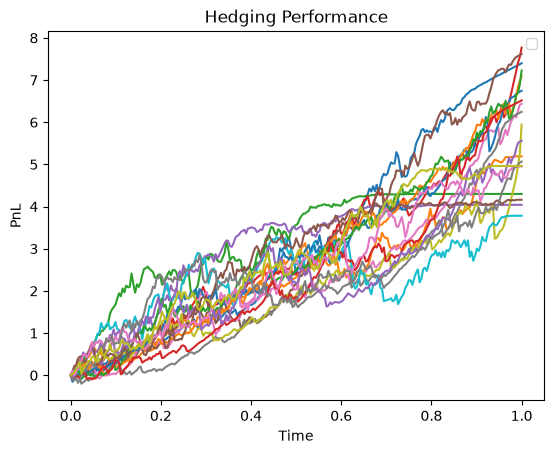

In [154]:
### Examples

# Hedging with actual volatility


#Params
S0 = 100
K = 110
T = 1
r = 0.05
D = 0.0
sigma_a = 0.20
sigma_i = 0.30
N = 252

#How many simulations to run
n_simluations = 20

pnl1, S1, t1 = PnL_hedged(S0, K, T, r, D, sigma_a, sigma_i, sigma_a, N)

for j in range(n_simluations-1):
    pnl1, S1, t1 = PnL_hedged(S0, K, T, r, D, sigma_a, sigma_i, sigma_a, N)
    plt.plot(t1, pnl1)

plt.xlabel('Time')
plt.ylabel('PnL')
plt.title('Hedging Performance')
plt.legend()
plt.show()
